# Introduction to PyTorch

## Overview

Previously, we built neural networks from scratch using NumPy. You implemented forward propagation, derived gradients by hand, coded backpropagation, and trained a network to classify handwritten digits.

**Now you understand what's really happening. It's time to work smarter.**

PyTorch automates the tedious parts - gradient computation, weight updates, GPU acceleration - while giving you complete control over your model architecture.

### Our Journey So Far

| File | Topic | Key Concept |
|--------|-------|-------------|
| first_neural_network | Neural Networks | Backpropagation, chain rule |
| deep-neural_network_numpy | Deep Networks | ReLU, softmax, MNIST from scratch |
| **deep-neural_network_with_pytorch** | **PyTorch** | **Automatic differentiation, frameworks** |

### What You'll Learn

- How `torch.Tensor` compares to `np.ndarray`
- **Autograd**: PyTorch computes gradients automatically
- `nn.Module`: The standard way to define neural networks
- `DataLoader`: Efficient batching and shuffling
- The standard PyTorch training loop pattern

### Same Problem, Less Code

We'll rebuild the **exact same MNIST classifier** from [deep-neural_network_numpy](deep-neural_network_numpy.ipynb) in PyTorch, so we can directly compare the two approaches.

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Data loading
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Check PyTorch version and device
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

PyTorch version: 2.8.0+cpu
Using device: cpu


## 2. Loading the MNIST Dataset

We use the **exact same dataset and preprocessing** as [deep-neural_network_numpy](deep-neural_network_numpy.ipynb) for direct comparison.

- 70,000 grayscale images of handwritten digits (0-9)
- Each image is 28×28 = 784 pixels
- We'll use a 10,000 sample subset with 80/20 train/test split

In [2]:
# Load MNIST - SAME AS PREVIOUS VERSION
print("Loading MNIST dataset (this may take a moment)...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')

X_full = mnist.data / 255.0  # Normalize to [0, 1]
y_full = mnist.target.astype(int)

print(f"\nDataset loaded!")
print(f"X shape: {X_full.shape}  (samples, pixels)")
print(f"y shape: {y_full.shape}  (samples,)")
print(f"Classes: {np.unique(y_full)}")

Loading MNIST dataset (this may take a moment)...

Dataset loaded!
X shape: (70000, 784)  (samples, pixels)
y shape: (70000,)  (samples,)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [3]:
# Use same subset as PREVIOUS VERSION
n_samples = 10000
X_subset = X_full[:n_samples]
y_subset = y_full[:n_samples]

# Split into training and test sets (same random_state as NumPy)
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 8000 samples
Test set: 2000 samples


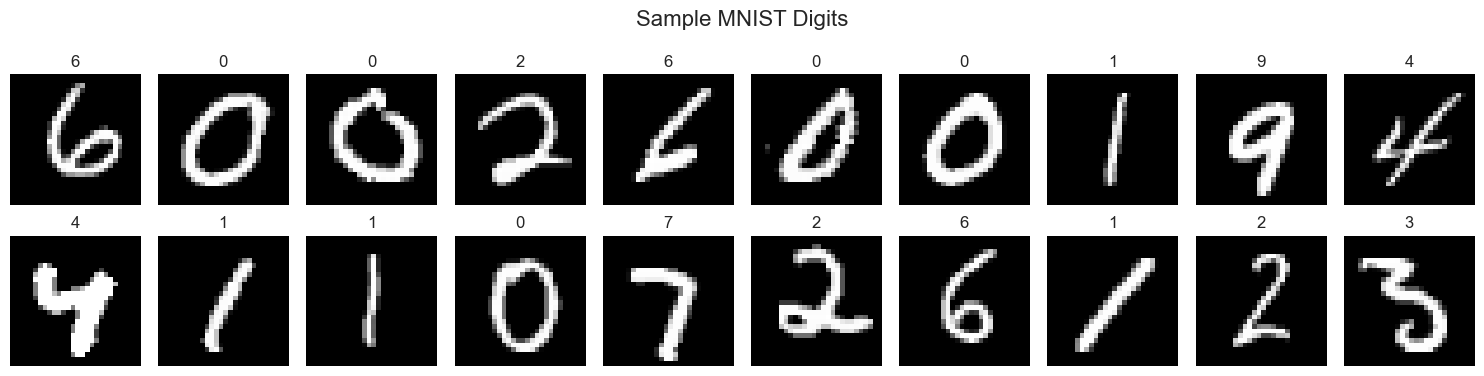

In [4]:
# Visualize some sample digits
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_train))
    ax.imshow(X_train[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"{y_train[idx]}", fontsize=12)
    ax.axis('off')

plt.suptitle('Sample MNIST Digits', fontsize=16)
plt.tight_layout()
plt.show()

## 3. NumPy vs PyTorch: Tensors

`torch.Tensor` is PyTorch's equivalent of `np.ndarray`.

**Key differences:**
- GPU support (move to CUDA with `.to('cuda')`)
- Automatic gradient tracking (`requires_grad=True`)
- Optimized for deep learning operations

In [5]:
# ============================================================
# NUMPY vs PYTORCH: Creating Arrays/Tensors
# ============================================================

# NumPy way
np_array = np.array([[1.0, 2.0], [3.0, 4.0]])
print("NumPy array:")
print(np_array)
print(f"Type: {type(np_array)}")

print("\n" + "="*50 + "\n")

# PyTorch way
torch_tensor = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print("PyTorch tensor:")
print(torch_tensor)
print(f"Type: {type(torch_tensor)}")
print(f"Device: {torch_tensor.device}")
print(f"Requires grad: {torch_tensor.requires_grad}")

NumPy array:
[[1. 2.]
 [3. 4.]]
Type: <class 'numpy.ndarray'>


PyTorch tensor:
tensor([[1., 2.],
        [3., 4.]])
Type: <class 'torch.Tensor'>
Device: cpu
Requires grad: False


In [6]:
# Converting between NumPy and PyTorch
np_to_torch = torch.from_numpy(np_array)
torch_to_np = torch_tensor.numpy()

print("NumPy to PyTorch:")
print(np_to_torch)
print(f"\nPyTorch to NumPy:")
print(torch_to_np)

NumPy to PyTorch:
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)

PyTorch to NumPy:
[[1. 2.]
 [3. 4.]]


In [7]:
# Operations comparison
print("NUMPY vs PYTORCH OPERATIONS")
print("="*60)
print(f"{'Operation':<25} {'NumPy':<20} {'PyTorch':<20}")
print("-"*60)
print(f"{'Matrix multiply':<25} {'np.dot(A, B)':<20} {'torch.mm(A, B)':<20}")
print(f"{'Element-wise multiply':<25} {'A * B':<20} {'A * B':<20}")
print(f"{'Sum':<25} {'np.sum(A)':<20} {'torch.sum(A)':<20}")
print(f"{'Mean':<25} {'np.mean(A)':<20} {'torch.mean(A)':<20}")
print(f"{'Max':<25} {'np.max(A)':<20} {'torch.max(A)':<20}")
print(f"{'Reshape':<25} {'A.reshape()':<20} {'A.view()':<20}")
print(f"{'Transpose':<25} {'A.T':<20} {'A.T':<20}")
print("="*60)

NUMPY vs PYTORCH OPERATIONS
Operation                 NumPy                PyTorch             
------------------------------------------------------------
Matrix multiply           np.dot(A, B)         torch.mm(A, B)      
Element-wise multiply     A * B                A * B               
Sum                       np.sum(A)            torch.sum(A)        
Mean                      np.mean(A)           torch.mean(A)       
Max                       np.max(A)            torch.max(A)        
Reshape                   A.reshape()          A.view()            
Transpose                 A.T                  A.T                 


## 4. Autograd: Automatic Differentiation

This is PyTorch's killer feature.

**In [deep-neural_nework](deep-neural_nework.ipynb), we manually derived and coded all gradients. PyTorch computes them automatically.**

How it works:
1. Create tensors with `requires_grad=True`
2. Perform computations (PyTorch builds a computational graph)
3. Call `.backward()` on the output
4. Gradients are stored in `.grad` attribute

In [8]:
# ============================================================
# AUTOGRAD: PyTorch computes gradients automatically!
# ============================================================

# Create tensor with gradient tracking
x = torch.tensor([2.0], requires_grad=True)

# Define a function: f(x) = x^2 + 3x + 1
y = x**2 + 3*x + 1

print(f"x = {x.item()}")
print(f"f(x) = x^2 + 3x + 1 = {y.item()}")

# Compute gradient automatically!
y.backward()

print(f"\nAutomatic gradient: df/dx = {x.grad.item()}")
print(f"Manual calculation: df/dx = 2x + 3 = 2({x.item()}) + 3 = {2*x.item() + 3}")

x = 2.0
f(x) = x^2 + 3x + 1 = 11.0

Automatic gradient: df/dx = 7.0
Manual calculation: df/dx = 2x + 3 = 2(2.0) + 3 = 7.0


In [9]:
# Autograd with matrix operations (like in neural networks)
W = torch.randn(3, 2, requires_grad=True)
x = torch.randn(2, 1)
b = torch.randn(3, 1, requires_grad=True)

# Forward pass
z = torch.mm(W, x) + b
a = torch.sigmoid(z)
loss = a.sum()

print("Forward pass:")
print(f"  z = W @ x + b, shape: {z.shape}")
print(f"  a = sigmoid(z), shape: {a.shape}")
print(f"  loss = sum(a) = {loss.item():.4f}")

# Backward pass - ONE LINE!
loss.backward()

print("\nGradients computed automatically:")
print(f"  dL/dW shape: {W.grad.shape}")
print(f"  dL/db shape: {b.grad.shape}")

Forward pass:
  z = W @ x + b, shape: torch.Size([3, 1])
  a = sigmoid(z), shape: torch.Size([3, 1])
  loss = sum(a) = 1.5476

Gradients computed automatically:
  dL/dW shape: torch.Size([3, 2])
  dL/db shape: torch.Size([3, 1])


### The Key Insight

| Task | NumPy | PyTorch |
|------|------------|---------------|
| Compute gradients | 25+ lines of manual code | `loss.backward()` |
| Derive math | Required for each architecture | Automatic |
| Debug gradients | Numerical gradient checking | Correct by construction |

## 5. Side-by-Side: NumPy vs PyTorch Forward Pass

Let's compare the forward pass code from NumPy with PyTorch.

In [10]:
# ============================================================
# NUMPY FORWARD PASS
# ============================================================

def relu_numpy(z):
    """ReLU activation function."""
    return np.maximum(0, z)

def softmax_numpy(z):
    """Softmax activation function (numerically stable)."""
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def forward_numpy(X, W1, W2, W3):
    """Forward pass - NumPy (code)"""
    z1 = np.dot(X, W1)      # Layer 1 linear
    a1 = relu_numpy(z1)      # Layer 1 activation
    
    z2 = np.dot(a1, W2)     # Layer 2 linear
    a2 = relu_numpy(z2)      # Layer 2 activation
    
    z3 = np.dot(a2, W3)     # Layer 3 linear
    h = softmax_numpy(z3)    # Output activation
    
    return z1, a1, z2, a2, z3, h

print("NumPy forward pass:")
print("  - Must manually implement ReLU")
print("  - Must manually implement softmax (with numerical stability)")
print("  - Must track all intermediate values for backprop")

NumPy forward pass:
  - Must manually implement ReLU
  - Must manually implement softmax (with numerical stability)
  - Must track all intermediate values for backprop


In [11]:
# ============================================================
# PYTORCH FORWARD PASS
# ============================================================

def forward_pytorch(X, W1, W2, W3):
    """Forward pass - PyTorch"""
    z1 = torch.mm(X, W1)
    a1 = torch.relu(z1)          # Built-in!
    
    z2 = torch.mm(a1, W2)
    a2 = torch.relu(z2)          # Built-in!
    
    z3 = torch.mm(a2, W3)
    h = torch.softmax(z3, dim=1) # Built-in!
    
    return z1, a1, z2, a2, z3, h

print("PyTorch forward pass:")
print("  - torch.relu() is built-in and optimized")
print("  - torch.softmax() is built-in and numerically stable")
print("  - All operations automatically track gradients!")

PyTorch forward pass:
  - torch.relu() is built-in and optimized
  - torch.softmax() is built-in and numerically stable
  - All operations automatically track gradients!


## 6. Side-by-Side: NumPy vs PyTorch Backward Pass

This is where PyTorch really shines.

In [12]:
# ============================================================
# NUMPY BACKWARD PASS - 25+ lines!
# ============================================================

def relu_derivative_numpy(z):
    """Derivative of ReLU: 1 if z > 0, else 0."""
    return (z > 0).astype(float)

def backward_numpy(X, Y, z1, a1, z2, a2, h, W2, W3):
    """Backpropagation - NumPy (code)"""
    m = len(Y)
    
    # Output layer error (softmax + cross-entropy -> h - Y)
    delta3 = h - Y                                      # (m, 10)
    
    # Gradient for W3
    dW3 = np.dot(a2.T, delta3) / m                      # (64, 10)
    
    # Hidden layer 2 error
    delta2 = np.dot(delta3, W3.T) * relu_derivative_numpy(z2) # (m, 64)
    
    # Gradient for W2
    dW2 = np.dot(a1.T, delta2) / m                      # (128, 64)
    
    # Hidden layer 1 error
    delta1 = np.dot(delta2, W2.T) * relu_derivative_numpy(z1) # (m, 128)
    
    # Gradient for W1
    dW1 = np.dot(X.T, delta1) / m                       # (784, 128)
    
    return dW1, dW2, dW3

print("NumPy backward pass: 25+ lines")
print("Must manually:")
print("  - Derive gradients mathematically")
print("  - Implement chain rule for each layer")
print("  - Track dimension at every step")
print("  - Easy to make mistakes!")

NumPy backward pass: 25+ lines
Must manually:
  - Derive gradients mathematically
  - Implement chain rule for each layer
  - Track dimension at every step
  - Easy to make mistakes!


In [13]:
# ============================================================
# PYTORCH BACKWARD PASS - 1 LINE!
# ============================================================

print("PyTorch backward pass:")
print()
print("    loss.backward()")
print()
print("That's it!")
print()
print("PyTorch automatically:")
print("  - Builds computational graph during forward pass")
print("  - Applies chain rule perfectly")
print("  - Handles ANY network architecture")
print("  - No manual gradient derivation!")

PyTorch backward pass:

    loss.backward()

That's it!

PyTorch automatically:
  - Builds computational graph during forward pass
  - Applies chain rule perfectly
  - Handles ANY network architecture
  - No manual gradient derivation!


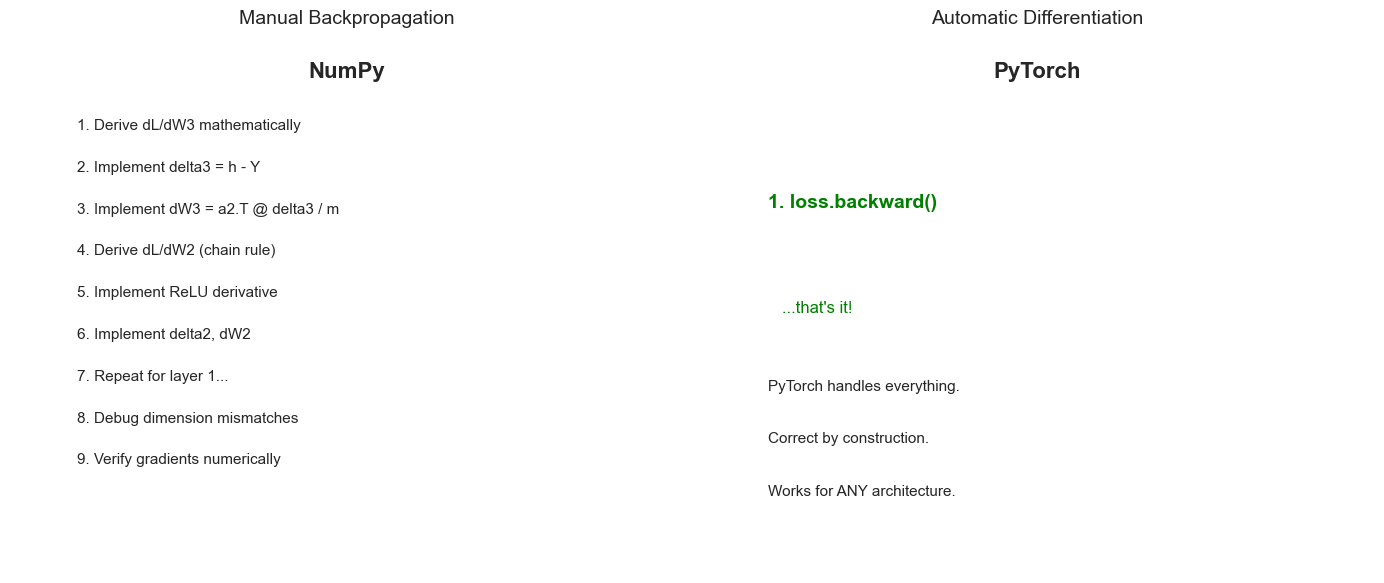

In [14]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# NumPy side
ax1 = axes[0]
ax1.text(0.5, 0.95, "NumPy", fontsize=16, fontweight='bold', 
         ha='center', transform=ax1.transAxes)
numpy_steps = [
    "1. Derive dL/dW3 mathematically",
    "2. Implement delta3 = h - Y",
    "3. Implement dW3 = a2.T @ delta3 / m",
    "4. Derive dL/dW2 (chain rule)",
    "5. Implement ReLU derivative",
    "6. Implement delta2, dW2",
    "7. Repeat for layer 1...",
    "8. Debug dimension mismatches",
    "9. Verify gradients numerically"
]
for i, step in enumerate(numpy_steps):
    ax1.text(0.1, 0.85 - i*0.08, step, fontsize=11, transform=ax1.transAxes)
ax1.axis('off')
ax1.set_title('Manual Backpropagation', fontsize=14, pad=20)

# PyTorch side
ax2 = axes[1]
ax2.text(0.5, 0.95, "PyTorch", fontsize=16, fontweight='bold', 
         ha='center', transform=ax2.transAxes)
ax2.text(0.1, 0.7, "1. loss.backward()", fontsize=14, transform=ax2.transAxes,
         color='green', fontweight='bold')
ax2.text(0.1, 0.5, "   ...that's it!", fontsize=12, transform=ax2.transAxes,
         color='green')
ax2.text(0.1, 0.35, "PyTorch handles everything.", fontsize=11, transform=ax2.transAxes)
ax2.text(0.1, 0.25, "Correct by construction.", fontsize=11, transform=ax2.transAxes)
ax2.text(0.1, 0.15, "Works for ANY architecture.", fontsize=11, transform=ax2.transAxes)
ax2.axis('off')
ax2.set_title('Automatic Differentiation', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

## 7. Building the Network with nn.Module

`nn.Module` is PyTorch's standard way to define neural networks.

Structure:
- `__init__`: Define the layers
- `forward`: Define the computation

We'll build the **exact same architecture**: 784 → 128 → 64 → 10

In [15]:
# ============================================================
# PYTORCH nn.Module - The Standard Way to Define Networks
# ============================================================

class MNISTClassifier(nn.Module):
    """
    Same architecture: 784 -> 128 -> 64 -> 10
    """
    def __init__(self):
        super(MNISTClassifier, self).__init__()
        
        # Define layers (weights are created automatically!)
        self.fc1 = nn.Linear(784, 128)  # Input -> Hidden1
        self.fc2 = nn.Linear(128, 64)   # Hidden1 -> Hidden2
        self.fc3 = nn.Linear(64, 10)    # Hidden2 -> Output
    
    def forward(self, x):
        # Define the forward pass
        x = torch.relu(self.fc1(x))     # Layer 1 + ReLU
        x = torch.relu(self.fc2(x))     # Layer 2 + ReLU
        x = self.fc3(x)                  # Output (no softmax - handled by loss)
        return x

# Create model
model = MNISTClassifier()
print(model)

MNISTClassifier(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [16]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nParameter breakdown:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.shape} = {param.numel():,} params")

print(f"\nNote: NumPy version had 109,184 params (weights only, no biases)")
print(f"PyTorch adds biases by default: 109,184 + 128 + 64 + 10 = {109184 + 128 + 64 + 10:,}")

Total parameters: 109,386
Trainable parameters: 109,386

Parameter breakdown:
  fc1.weight: torch.Size([128, 784]) = 100,352 params
  fc1.bias: torch.Size([128]) = 128 params
  fc2.weight: torch.Size([64, 128]) = 8,192 params
  fc2.bias: torch.Size([64]) = 64 params
  fc3.weight: torch.Size([10, 64]) = 640 params
  fc3.bias: torch.Size([10]) = 10 params

Note: NumPy version had 109,184 params (weights only, no biases)
PyTorch adds biases by default: 109,184 + 128 + 64 + 10 = 109,386


In [17]:
print("\n" + "="*60)
print("ARCHITECTURE COMPARISON: NumPy vs PyTorch")
print("="*60)
print(f"{'Component':<20} {'NumPy':<20} {'PyTorch':<20}")
print("-"*60)
print(f"{'Layer definition':<20} {'Manual W matrices':<20} {'nn.Linear()':<20}")
print(f"{'Weight init':<20} {'He init (manual)':<20} {'Automatic':<20}")
print(f"{'Bias terms':<20} {'Not included':<20} {'Included by default':<20}")
print(f"{'Forward pass':<20} {'Manual np.dot()':<20} {'self.fc1(x)':<20}")
print(f"{'Activation':<20} {'Manual relu()':<20} {'torch.relu()':<20}")
print("="*60)


ARCHITECTURE COMPARISON: NumPy vs PyTorch
Component            NumPy                PyTorch             
------------------------------------------------------------
Layer definition     Manual W matrices    nn.Linear()         
Weight init          He init (manual)     Automatic           
Bias terms           Not included         Included by default 
Forward pass         Manual np.dot()      self.fc1(x)         
Activation           Manual relu()        torch.relu()        


## 8. DataLoader: Efficient Data Handling

`DataLoader` handles batching, shuffling, and parallel data loading automatically.

Compare with manual batching in [deep-neural_network_numpy](deep-neural_network_numpy.ipynb)/SGD lessons.

In [18]:
# ============================================================
# DATALOADER: Handles batching and shuffling automatically
# ============================================================

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print(f"X_train tensor: {X_train_tensor.shape}, dtype: {X_train_tensor.dtype}")
print(f"y_train tensor: {y_train_tensor.shape}, dtype: {y_train_tensor.dtype}")

X_train tensor: torch.Size([8000, 784]), dtype: torch.float32
y_train tensor: torch.Size([8000]), dtype: torch.int64


In [19]:
# Create datasets and data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {batch_size}")

# Show one batch
X_batch, y_batch = next(iter(train_loader))
print(f"\nOne batch: X shape = {X_batch.shape}, y shape = {y_batch.shape}")

Training batches: 125
Test batches: 32
Batch size: 64

One batch: X shape = torch.Size([64, 784]), y shape = torch.Size([64])


In [20]:
print("\n" + "="*60)
print("DATA HANDLING: Manual (SGD) vs DataLoader")
print("="*60)
print("Manual (NumPy):")
print("  indices = np.random.permutation(m)")
print("  for start in range(0, m, batch_size):")
print("      X_batch = X_shuffled[start:end]")
print("      ...")
print("\nDataLoader (PyTorch):")
print("  for X_batch, y_batch in train_loader:")
print("      ...")
print("\nDataLoader also supports:")
print("  - Parallel data loading (num_workers)")
print("  - Pin memory for faster GPU transfer")
print("  - Custom samplers")
print("="*60)


DATA HANDLING: Manual (SGD) vs DataLoader
Manual (NumPy):
  indices = np.random.permutation(m)
  for start in range(0, m, batch_size):
      X_batch = X_shuffled[start:end]
      ...

DataLoader (PyTorch):
  for X_batch, y_batch in train_loader:
      ...

DataLoader also supports:
  - Parallel data loading (num_workers)
  - Pin memory for faster GPU transfer
  - Custom samplers


## 9. Loss Function and Optimizer

**Loss function:** `nn.CrossEntropyLoss` combines softmax and cross-entropy loss.

**Optimizer:** Handles weight updates automatically. We'll use `optim.SGD` to match [deep-neural_network_numpy](deep-neural_network_numpy.ipynb).

In [21]:
# ============================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================

# Loss function (combines softmax + cross-entropy)
criterion = nn.CrossEntropyLoss()

# Optimizer (handles weight updates automatically)
optimizer = optim.SGD(model.parameters(), lr=0.1)

print("Loss function: nn.CrossEntropyLoss()")
print("  - Combines softmax and cross-entropy")
print("  - Numerically stable")
print("  - No need to implement softmax in forward()")

print("\nOptimizer: optim.SGD(model.parameters(), lr=0.1)")
print("  - Automatically gets all model parameters")
print("  - Handles weight updates")
print("  - Can easily switch to Adam, RMSprop, etc.")

Loss function: nn.CrossEntropyLoss()
  - Combines softmax and cross-entropy
  - Numerically stable
  - No need to implement softmax in forward()

Optimizer: optim.SGD(model.parameters(), lr=0.1)
  - Automatically gets all model parameters
  - Handles weight updates
  - Can easily switch to Adam, RMSprop, etc.


In [22]:
print("\n" + "="*60)
print("WEIGHT UPDATE: Manual vs Optimizer")
print("="*60)
print("Manual (NumPy):")
print("  dW1, dW2, dW3 = backward(...)")
print("  W1 = W1 - lr * dW1")
print("  W2 = W2 - lr * dW2")
print("  W3 = W3 - lr * dW3")
print("\nPyTorch:")
print("  optimizer.zero_grad()  # Clear old gradients")
print("  loss.backward()        # Compute gradients")
print("  optimizer.step()       # Update all weights")
print("="*60)


WEIGHT UPDATE: Manual vs Optimizer
Manual (NumPy):
  dW1, dW2, dW3 = backward(...)
  W1 = W1 - lr * dW1
  W2 = W2 - lr * dW2
  W3 = W3 - lr * dW3

PyTorch:
  optimizer.zero_grad()  # Clear old gradients
  loss.backward()        # Compute gradients
  optimizer.step()       # Update all weights


## 10. The PyTorch Training Loop

This is the standard pattern used in virtually all PyTorch projects.

```python
for epoch in range(epochs):
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()      # 1. Clear gradients
        outputs = model(X_batch)   # 2. Forward pass
        loss = criterion(outputs, y_batch)
        loss.backward()            # 3. Backward pass
        optimizer.step()           # 4. Update weights
```

In [23]:
# ============================================================
# THE PYTORCH TRAINING LOOP
# ============================================================

def train_pytorch(model, train_loader, test_loader, criterion, optimizer, epochs=50):
    """
    Standard PyTorch training loop.
    """
    history = {
        'train_loss': [], 'test_loss': [],
        'train_acc': [], 'test_acc': []
    }
    
    for epoch in range(epochs):
        # ============ TRAINING PHASE ============
        model.train()  # Set model to training mode
        train_loss = 0.0
        correct = 0
        total = 0
        
        for X_batch, y_batch in train_loader:
            # 1. Zero gradients
            optimizer.zero_grad()
            
            # 2. Forward pass
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # 3. Backward pass
            loss.backward()
            
            # 4. Update weights
            optimizer.step()
            
            # Track metrics
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        
        train_loss /= len(train_loader)
        train_acc = correct / total
        
        # ============ EVALUATION PHASE ============
        model.eval()  # Set model to evaluation mode
        test_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():  # No gradient computation needed
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        
        test_loss /= len(test_loader)
        test_acc = correct / total
        
        # Save history
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}: "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2%} | "
                  f"Test Acc: {test_acc:.2%}")
    
    return history

In [24]:
# Reset model and optimizer
model = MNISTClassifier()
optimizer = optim.SGD(model.parameters(), lr=0.1)

print("Training PyTorch model...")
print("Architecture: 784 -> 128 -> 64 -> 10")
print("="*70)

history_pytorch = train_pytorch(
    model, train_loader, test_loader, 
    criterion, optimizer, 
    epochs=50
)

print("="*70)
print(f"Final Test Accuracy: {history_pytorch['test_acc'][-1]:.2%}")

Training PyTorch model...
Architecture: 784 -> 128 -> 64 -> 10
Epoch   1/50: Train Loss: 1.5770, Train Acc: 57.48% | Test Acc: 78.55%
Epoch   5/50: Train Loss: 0.2817, Train Acc: 91.90% | Test Acc: 92.60%
Epoch  10/50: Train Loss: 0.1620, Train Acc: 95.12% | Test Acc: 94.40%
Epoch  15/50: Train Loss: 0.0941, Train Acc: 97.34% | Test Acc: 94.55%
Epoch  20/50: Train Loss: 0.0550, Train Acc: 98.70% | Test Acc: 95.50%
Epoch  25/50: Train Loss: 0.0307, Train Acc: 99.42% | Test Acc: 95.55%
Epoch  30/50: Train Loss: 0.0176, Train Acc: 99.76% | Test Acc: 95.85%
Epoch  35/50: Train Loss: 0.0094, Train Acc: 99.94% | Test Acc: 95.90%
Epoch  40/50: Train Loss: 0.0061, Train Acc: 99.99% | Test Acc: 95.80%
Epoch  45/50: Train Loss: 0.0043, Train Acc: 100.00% | Test Acc: 95.95%
Epoch  50/50: Train Loss: 0.0033, Train Acc: 100.00% | Test Acc: 96.05%
Final Test Accuracy: 96.05%


## 11. Visualizing Training Progress

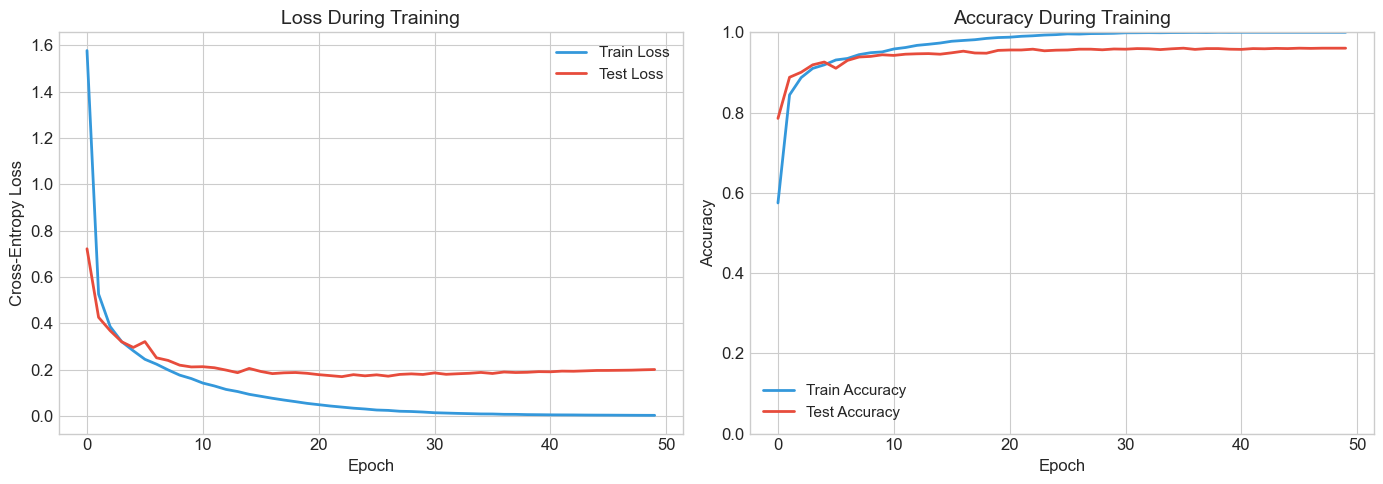

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
ax1 = axes[0]
ax1.plot(history_pytorch['train_loss'], linewidth=2, color='#3498db', label='Train Loss')
ax1.plot(history_pytorch['test_loss'], linewidth=2, color='#e74c3c', label='Test Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.set_title('Loss During Training', fontsize=14)
ax1.legend(fontsize=11)

# Plot 2: Accuracy
ax2 = axes[1]
ax2.plot(history_pytorch['train_acc'], linewidth=2, color='#3498db', label='Train Accuracy')
ax2.plot(history_pytorch['test_acc'], linewidth=2, color='#e74c3c', label='Test Accuracy')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy During Training', fontsize=14)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## 12. Results Comparison: NumPy vs PyTorch

In [26]:
# ============================================================
# RESULTS COMPARISON: NumPy vs PyTorch
# ============================================================

print("="*70)
print("FINAL COMPARISON: NumPy vs PyTorch")
print("="*70)
print(f"{'Metric':<25} {'NumPy':<20} {'PyTorch':<20}")
print("-"*70)
test_acc = f"{history_pytorch['test_acc'][-1]:.2%}"
print(f"{'Test Accuracy':<25} {'~86%':<20} {test_acc:<20}")
print(f"{'Lines of code':<25} {'~150':<20} {'~50':<20}")
print(f"{'Manual gradients':<25} {'Yes (25+ lines)':<20} {'No (automatic)':<20}")
print(f"{'GPU support':<25} {'No':<20} {'Yes (1 line change)':<20}")
print(f"{'Change architecture':<25} {'Rewrite backprop':<20} {'Just edit layers':<20}")
print("="*70)

FINAL COMPARISON: NumPy vs PyTorch
Metric                    NumPy                PyTorch             
----------------------------------------------------------------------
Test Accuracy             ~86%                 96.05%              
Lines of code             ~150                 ~50                 
Manual gradients          Yes (25+ lines)      No (automatic)      
GPU support               No                   Yes (1 line change) 
Change architecture       Rewrite backprop     Just edit layers    


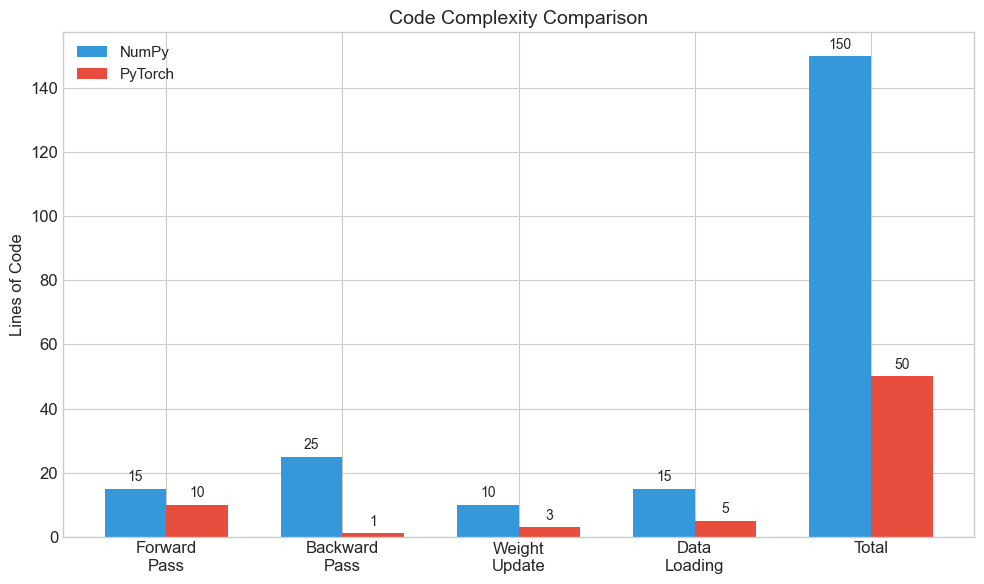

In [27]:
# Code complexity visualization
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Forward\nPass', 'Backward\nPass', 'Weight\nUpdate', 'Data\nLoading', 'Total']
numpy_lines = [15, 25, 10, 15, 150]
pytorch_lines = [10, 1, 3, 5, 50]

x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, numpy_lines, width, label='NumPy', color='#3498db')
bars2 = ax.bar(x + width/2, pytorch_lines, width, label='PyTorch', color='#e74c3c')

ax.set_ylabel('Lines of Code', fontsize=12)
ax.set_title('Code Complexity Comparison', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(fontsize=11)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 13. Experiment: SGD vs Adam

One of PyTorch's benefits is easily swapping optimizers.

In NumPy's version, changing optimizers would require rewriting the entire training loop. In PyTorch, it's one line.

In [28]:
# ============================================================
# EXPERIMENT: SGD vs Adam
# ============================================================

# Train with SGD
print("Training with SGD (lr=0.1)...")
model_sgd = MNISTClassifier()
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.1)
history_sgd = train_pytorch(model_sgd, train_loader, test_loader, criterion, optimizer_sgd, epochs=30)

Training with SGD (lr=0.1)...
Epoch   1/30: Train Loss: 1.5288, Train Acc: 60.55% | Test Acc: 82.35%
Epoch   5/30: Train Loss: 0.2669, Train Acc: 92.27% | Test Acc: 92.80%
Epoch  10/30: Train Loss: 0.1530, Train Acc: 95.71% | Test Acc: 94.65%
Epoch  15/30: Train Loss: 0.0882, Train Acc: 97.70% | Test Acc: 94.75%
Epoch  20/30: Train Loss: 0.0494, Train Acc: 98.86% | Test Acc: 95.45%
Epoch  25/30: Train Loss: 0.0256, Train Acc: 99.60% | Test Acc: 95.25%
Epoch  30/30: Train Loss: 0.0142, Train Acc: 99.88% | Test Acc: 95.70%


In [29]:
# Train with Adam
print("\nTraining with Adam (lr=0.001)...")
model_adam = MNISTClassifier()
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)
history_adam = train_pytorch(model_adam, train_loader, test_loader, criterion, optimizer_adam, epochs=30)


Training with Adam (lr=0.001)...
Epoch   1/30: Train Loss: 0.8472, Train Acc: 78.42% | Test Acc: 89.20%
Epoch   5/30: Train Loss: 0.1862, Train Acc: 94.73% | Test Acc: 93.95%
Epoch  10/30: Train Loss: 0.0764, Train Acc: 97.80% | Test Acc: 94.85%
Epoch  15/30: Train Loss: 0.0301, Train Acc: 99.30% | Test Acc: 94.95%
Epoch  20/30: Train Loss: 0.0117, Train Acc: 99.75% | Test Acc: 94.80%
Epoch  25/30: Train Loss: 0.0034, Train Acc: 100.00% | Test Acc: 95.30%
Epoch  30/30: Train Loss: 0.0015, Train Acc: 100.00% | Test Acc: 95.15%


In [30]:
# Compare
print("\n" + "="*50)
print("OPTIMIZER COMPARISON")
print("="*50)
print(f"SGD Final Accuracy:  {history_sgd['test_acc'][-1]:.2%}")
print(f"Adam Final Accuracy: {history_adam['test_acc'][-1]:.2%}")


OPTIMIZER COMPARISON
SGD Final Accuracy:  95.70%
Adam Final Accuracy: 95.15%


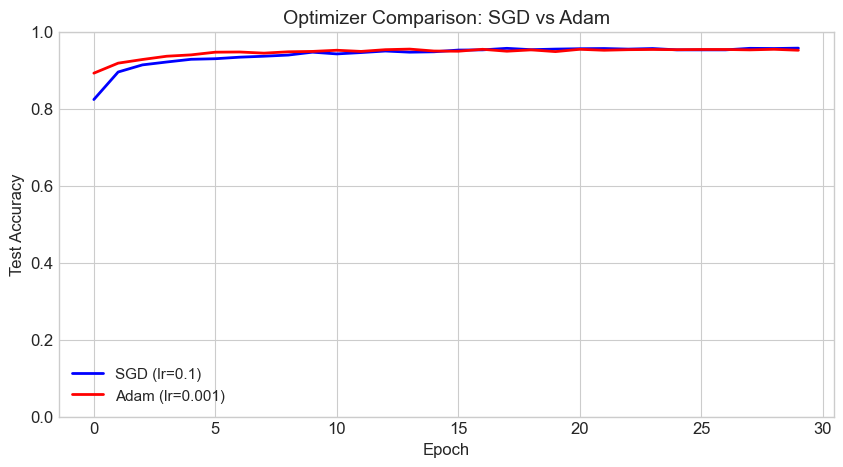


Observation: Adam often converges faster due to adaptive learning rates.
In Numpy's Version, changing optimizers would require rewriting the entire training loop!


In [31]:
plt.figure(figsize=(10, 5))
plt.plot(history_sgd['test_acc'], 'b-', linewidth=2, label='SGD (lr=0.1)')
plt.plot(history_adam['test_acc'], 'r-', linewidth=2, label='Adam (lr=0.001)')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Optimizer Comparison: SGD vs Adam', fontsize=14)
plt.legend(fontsize=11)
plt.ylim(0, 1)
plt.show()

print("\nObservation: Adam often converges faster due to adaptive learning rates.")
print("In Numpy's Version, changing optimizers would require rewriting the entire training loop!")

## 14. Visualizing Predictions

In [32]:
# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    _, predictions = torch.max(outputs, 1)
    predictions = predictions.numpy()

true_labels = y_test

# Calculate accuracy
correct_mask = predictions == true_labels
print(f"Test Accuracy: {correct_mask.mean():.2%}")
print(f"Correct predictions: {correct_mask.sum()}")
print(f"Incorrect predictions: {(~correct_mask).sum()}")

Test Accuracy: 96.05%
Correct predictions: 1921
Incorrect predictions: 79


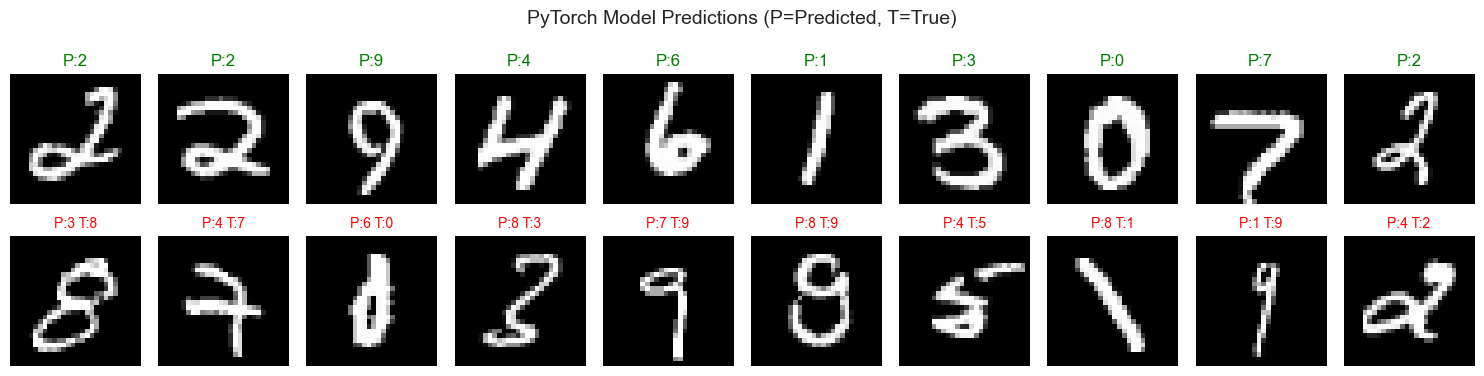

In [33]:
# Visualize predictions (same format as NumPy)
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# Top row: Correct predictions
correct_indices = np.where(correct_mask)[0]
for i, ax in enumerate(axes[0]):
    idx = correct_indices[np.random.randint(len(correct_indices))]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    ax.set_title(f"P:{predictions[idx]}", color='green', fontsize=12)
    ax.axis('off')

# Bottom row: Incorrect predictions
incorrect_indices = np.where(~correct_mask)[0]
for i, ax in enumerate(axes[1]):
    if i < len(incorrect_indices):
        idx = incorrect_indices[i]
        ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
        ax.set_title(f"P:{predictions[idx]} T:{true_labels[idx]}", color='red', fontsize=10)
    ax.axis('off')

axes[0, 0].set_ylabel('Correct', fontsize=12)
axes[1, 0].set_ylabel('Wrong', fontsize=12)
plt.suptitle('PyTorch Model Predictions (P=Predicted, T=True)', fontsize=14)
plt.tight_layout()
plt.show()

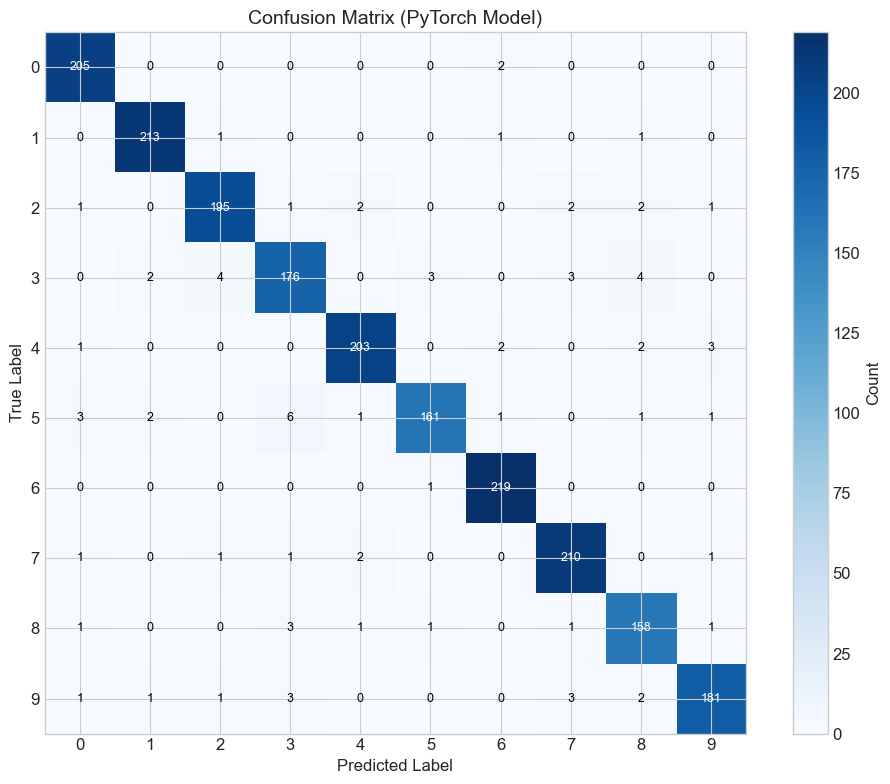


Per-class accuracy:
  Digit 0: 99.0%
  Digit 1: 98.6%
  Digit 2: 95.6%
  Digit 3: 91.7%
  Digit 4: 96.2%
  Digit 5: 91.5%
  Digit 6: 99.5%
  Digit 7: 97.2%
  Digit 8: 95.2%
  Digit 9: 94.3%


In [34]:
# Confusion matrix
confusion = np.zeros((10, 10), dtype=int)
for true, pred in zip(true_labels, predictions):
    confusion[true, pred] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confusion, cmap='Blues')

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix (PyTorch Model)', fontsize=14)

for i in range(10):
    for j in range(10):
        text = ax.text(j, i, confusion[i, j], ha='center', va='center', 
                      color='white' if confusion[i, j] > confusion.max()/2 else 'black',
                      fontsize=9)

plt.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i in range(10):
    class_acc = confusion[i, i] / confusion[i].sum() if confusion[i].sum() > 0 else 0
    print(f"  Digit {i}: {class_acc:.1%}")

## 15. Summary

### What PyTorch Automates

| Task | NumPy | PyTor |
|------|------------|---------------|
| Gradient computation | Manual derivation & code | `loss.backward()` |
| Weight updates | Manual loop over weights | `optimizer.step()` |
| Activation functions | Implement from scratch | `torch.relu()`, etc. |
| Loss functions | Implement from scratch | `nn.CrossEntropyLoss()` |
| Batching & shuffling | Manual indexing | `DataLoader` |
| GPU acceleration | Not available | `model.to('cuda')` |

### The PyTorch Training Pattern

```python
for epoch in range(epochs):
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()      # Clear gradients
        outputs = model(X_batch)   # Forward pass
        loss = criterion(outputs, y_batch)
        loss.backward()            # Backward pass
        optimizer.step()           # Update weights
```

### Key Takeaways

1. **Understanding fundamentals helps to debug and improve PyTorch code**
2. **PyTorch automates tedious parts while giving you full control**
3. **Same accuracy, 1/3 the code, and GPU-ready**
4. **Easy to experiment with different architectures and optimizers**

### What's Next

- **Convolutional Neural Networks (CNNs)** for image classification
- **Regularization techniques** (Dropout, BatchNorm)
- **Transfer Learning** with pre-trained models

In [35]:
print("="*70)
print("SUMMARY: Introduction to PyTorch")
print("="*70)
print(f"Dataset:           MNIST (same as NumPy)")
print(f"Architecture:      784 -> 128 -> 64 -> 10 (same as NumPy)")
print(f"Framework:         PyTorch {torch.__version__}")
print(f"Final Test Acc:    {history_pytorch['test_acc'][-1]:.2%}")
print(f"Lines of code:     ~50 (vs ~150 in NumPy)")
print("="*70)
print("\nKey PyTorch concepts covered:")
print("  - torch.Tensor (like np.ndarray but with autograd)")
print("  - autograd (automatic differentiation)")
print("  - nn.Module (defining network architectures)")
print("  - DataLoader (efficient data handling)")
print("  - Optimizers (SGD, Adam)")
print("  - Standard training loop pattern")
print("="*70)

SUMMARY: Introduction to PyTorch
Dataset:           MNIST (same as NumPy)
Architecture:      784 -> 128 -> 64 -> 10 (same as NumPy)
Framework:         PyTorch 2.8.0+cpu
Final Test Acc:    96.05%
Lines of code:     ~50 (vs ~150 in NumPy)

Key PyTorch concepts covered:
  - torch.Tensor (like np.ndarray but with autograd)
  - autograd (automatic differentiation)
  - nn.Module (defining network architectures)
  - DataLoader (efficient data handling)
  - Optimizers (SGD, Adam)
  - Standard training loop pattern
